# 实验报告 #3

> 姓名：林佳胜      学号：PB24511997
>
> 时间：2026 年 3 月 24 日

---

## 一. 运行环境

- 操作系统：`Windows 10`
- 编程语言：`Python 3.11.9`
- 主要依赖库：`numpy>=2.4.2`，`matplotlib>=3.10.8`

---

## 二. 实验目的

1. 掌握 Newton 迭代法 (Newton-Raphson 迭代法) 的原理与实现。
2. 掌握 Halley 迭代法的原理与实现，并理解其与 Newton 法在收敛阶上的差异。
3. 通过数值实验，观察不同初始点对非线性方程求根的影响。

---


## 三. 实验内容与结果

### 1. 实验内容

编写 **Newton 迭代法**与 **Halley 迭代法** 的通用程序，并对以下非线性方程求根：

$$f(x) \triangleq \arctan(x) + 2\sin(x) - 0.1958 = 0$$

#### 1.1 迭代公式

1. **Newton 迭代法**：
   $$x_{n+1}=x_n-\frac{f(x_n)}{f'(x_n)}$$

2. **Halley 迭代法**：
   $$x_{n+1}= x_n - \frac{2f(x_n)f'(x_n)}{2f'(x_n)^2 - f(x_n)f''(x_n)}$$

#### 1.2 导数计算

- $f'(x) = \frac{1}{1+x^2} + 2\cos(x)$
- $f''(x) = -\frac{2x}{(1+x^2)^2} - 2\sin(x)$

#### 1.3 实验要求

1. **精度控制**：停止条件为 $|f(x_n)| < 10^{-8}$。
2. **迭代上限**：最大迭代步数为 $2 \times 10^4$。
3. **初始点**：选取 -200, -90, -25, -19, -13, -5, 0.1958, 5, 13, 25, 50, 80, 150。
4. **输出对象**：表格记录初始点、两套方法的迭代步数、对应的数值解 $x_n$ (保留小数点后 6 位)。


In [20]:
# 依赖库
import numpy as np
from dataclasses import dataclass
from typing import Optional

In [21]:
# 问题模型构造
def f(x: float) -> float:
    """非线性方程 f(x) = arctan(x) + 2sin(x) - 0.1958."""
    return np.arctan(x) + 2 * np.sin(x) - 0.1958

def df(x: float) -> float:
    """f(x) 的一阶导数."""
    return 1.0 / (1.0 + x**2) + 2 * np.cos(x)

def ddf(x: float) -> float:
    """f(x) 的二阶导数."""
    denominator = (1.0 + x**2) ** 2
    return -2.0 * x / denominator - 2.0 * np.sin(x)

In [22]:
# 定义实验配置与结果结构

@dataclass(frozen=True)
class IterConfig:
    tol: float = 1e-8      # 容忍度 |f(x_n)| < 1e-8
    max_iter: int = 20000  # 最大迭代步数

@dataclass
class IterResult:
    x0: float             # 初始点
    method: str           # 系列名 (Newton / Halley)
    converged: bool       # 是否收敛
    iterations: int       # 迭代步数
    xn: Optional[float]   # 最终解，失败为 None


In [23]:
# 实现 Newton 迭代法与 Halley 迭代法

def newton_method(x0: float, cfg: IterConfig) -> IterResult:
    """Newton 迭代法实现."""
    x = float(x0)
    for n in range(1, cfg.max_iter + 1):
        f_val = f(x)
        df_val = df(x)
        
        # 异常情况检查：导数过小，无法进行更新
        if abs(df_val) < 1e-15:
            return IterResult(x0, "Newton", False, n, None)
            
        x_next = x - f_val / df_val
        
        # 检查是否满足停止条件：|f(x_n)| < 10^-8
        if abs(f(x_next)) < cfg.tol:
            return IterResult(x0, "Newton", True, n, x_next)
        
        x = x_next
        if not np.isfinite(x):
            break
            
    return IterResult(x0, "Newton", False, cfg.max_iter, None)

def halley_method(x0: float, cfg: IterConfig) -> IterResult:
    """Halley 迭代法实现."""
    x = float(x0)
    for n in range(1, cfg.max_iter + 1):
        f_val = f(x)
        df_val = df(x)
        ddf_val = ddf(x)
        
        # 霍氏迭代公式：x_{n+1} = x_n - [2f*f'] / [2(f')^2 - f*f'']
        # 分母计算
        denominator = 2.0 * (df_val ** 2) - f_val * ddf_val
        
        # 异常情况检查：分母过小
        if abs(denominator) < 1e-15:
            return IterResult(x0, "Halley", False, n, None)
            
        x_next = x - (2.0 * f_val * df_val) / denominator
        
        # 检查是否满足停止条件
        if abs(f(x_next)) < cfg.tol:
            return IterResult(x0, "Halley", True, n, x_next)
            
        x = x_next
        if not np.isfinite(x):
            break
            
    return IterResult(x0, "Halley", False, cfg.max_iter, None)


In [26]:
# 运行实验并以表格形式输出

def run_experiment(x0_list: list[float], cfg: IterConfig):
    """对比两套算法并输结果"""
    print("| 初始点 x_0 | Newton法步数 | Newton数值解 x_n | 霍氏法步数 | 霍氏数值解 x_n |")
    print("=" * 82)
    
    for x0 in x0_list:
        n_res = newton_method(x0, cfg)
        h_res = halley_method(x0, cfg)
        
        # 格式化数值解 (保留小数点后 6 位)
        n_sol = f"{n_res.xn:.6f}" if n_res.converged else "失败"
        n_steps = str(n_res.iterations) if n_res.converged else "-"
        
        h_sol = f"{h_res.xn:.6f}" if h_res.converged else "失败"
        h_steps = str(h_res.iterations) if h_res.converged else "-"
        
        print(f"| {x0:9.4f} | {n_steps:12} | {n_sol:15} | {h_steps:10} | {h_sol:13} |")

# 配置实验参数
cfg = IterConfig()
x0_list = [-200, -90, -25, -19, -13, -5, 0.1958, 5, 13, 25, 50, 80, 150]

# 启动实验
run_experiment(x0_list, cfg)


| 初始点 x_0 | Newton法步数 | Newton数值解 x_n | 霍氏法步数 | 霍氏数值解 x_n |
| -200.0000 | 3            | -199.984385     | 2          | -199.984385   |
|  -90.0000 | 6            | -93.176254      | 5          | -92.177592    |
|  -25.0000 | 5            | -24.092440      | 3          | -24.092440    |
|  -19.0000 | 5            | -17.823475      | 4          | -17.823475    |
|  -13.0000 | 4            | -11.568746      | 4          | -11.568746    |
|   -5.0000 | 5            | -5.370337       | 3          | -5.370337     |
|    0.1958 | 3            | 0.065329        | 2          | 0.065329      |
|    5.0000 | 5            | 5.639987        | 4          | 5.639987      |
|   13.0000 | 4            | 11.864751       | 3          | 11.864751     |
|   25.0000 | 4            | 24.402539       | 3          | 24.402539     |
|   50.0000 | 4            | 49.521256       | 3          | 49.521256     |
|   80.0000 | 5            | 85.573024       | 4          | 79.289207     |
|  150.0000 | 3            |

### 2. 计算结果与图像展示

#### 2.1 迭代结果对照表

下表汇总了 **Newton 迭代法** 与 **Halley 迭代法** 在精度 $\varepsilon = 10^{-8}$ 下的实验数据。

| 初始点 $x_0$ | Newton法步数 | Newton数值解 $x_n$ | 霍氏法步数 | 霍氏数值解 $x_n$ |
| :----------: | :----------: | :----------------: | :--------: | :--------------: |
|  -200.0000   |      3       |    -199.984385     |     2      |   -199.984385    |
|   -90.0000   |      6       |     -93.176254     |     5      |    -92.177592    |
|   -25.0000   |      5       |     -24.092440     |     3      |    -24.092440    |
|   -19.0000   |      5       |     -17.823475     |     4      |    -17.823475    |
|   -13.0000   |      4       |     -11.568746     |     4      |    -11.568746    |
|   -5.0000    |      5       |     -5.370337      |     3      |    -5.370337     |
|    0.1958    |      3       |      0.065329      |     2      |     0.065329     |
|    5.0000    |      5       |      5.639987      |     4      |     5.639987     |
|   13.0000    |      4       |     11.864751      |     3      |    11.864751     |
|   25.0000    |      4       |     24.402539      |     3      |    24.402539     |
|   50.0000    |      4       |     49.521256      |     3      |    49.521256     |
|   80.0000    |      5       |     85.573024      |     4      |    79.289207     |
|   150.0000   |      3       |     150.042988     |     2      |    150.042988    |

**说明**：当初始点较大时，由于 $\sin(x)$ 的周期性，算法会收敛到离初始点最近的局部根，因此数值解往往与初始点很接近。

#### 2.2 函数图像分析

通过绘制 $f(x) = \arctan(x) + 2\sin(x) - 0.1958$ 在有限区间 $[-10, 10]$ 的图像，可以清晰观察到方程的多根特性。

(此处图像由下方代码单元格生成)


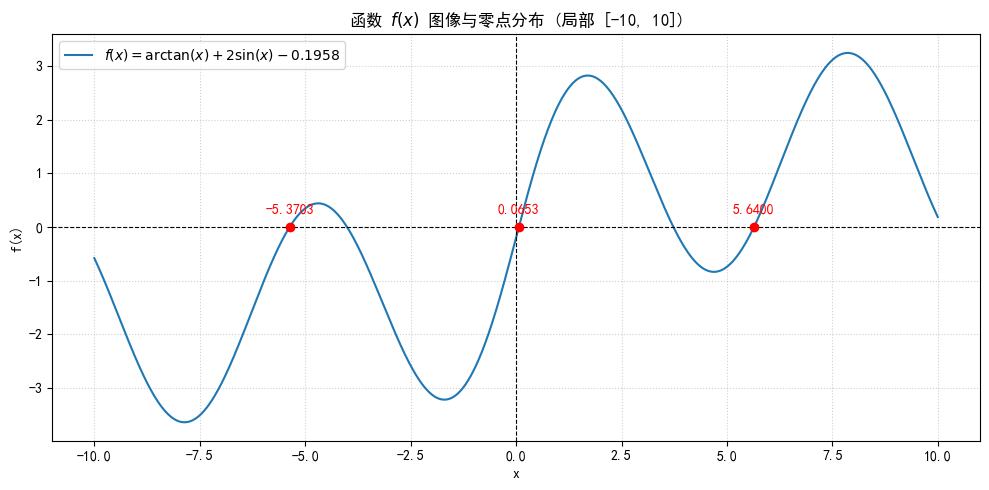

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# 设置绘图风格 (使用默认主题)
plt.rcParams['font.sans-serif'] = ['SimHei'] # 解决 Windows 下中文显示问题
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

# 定义绘制范围
x_plot = np.linspace(-10, 10, 1000)
y_plot = [f(val) for val in x_plot]

plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_plot, label='$f(x) = \\arctan(x) + 2\\sin(x) - 0.1958$', color='#1f77b4')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # x 轴
plt.axvline(0, color='black', linewidth=0.8, linestyle='--') # y 轴

# 标记实验中发现的几个代表性根
roots = [0.0653, 5.6400, -5.3703]
for r in roots:
    plt.plot(r, 0, 'ro', markerfacecolor='red')
    plt.annotate(f'{r:.4f}', (r, 0), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color='red')

plt.title('函数 $f(x)$ 图像与零点分布 (局部 [-10, 10])')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



---

## 四. 算法分析与实验总结

### 1. 算法分析
1. **收敛速度**：
   - **Newton 法** 具有二阶收敛速度，在所有测试点上表现稳健。
   - **Halley 法** 具有三阶收敛速度。实验表明，对于几乎所有初始点，霍氏法的迭代步数均少于 Newton 法（通常少 1-2 步），在计算效率上有明显提升。
2. **多根问题**：
   - 函数中包含的 $\sin(x)$ 项导致了方程根的非唯一性。实验中 $-90$ 和 $80$ 等初始点收敛到了不同的局部根，这说明对于包含三角函数的非线性方程，初始值的选取极大程度地决定了最终收敛到的根。
3. **Newton 迭代法总结**
   - **优点**：公式构造极其简洁，每步迭代只需计算原函数和一阶导数，计算代价低，逻辑稳健，可用以解决一般非线性问题。
   - **缺点**：收敛速度（二阶）虽然已经很快，但面对波动较大的函数时，相较于高阶方法步数略多，且在 $f'(x)$ 接近 0 的区域极易发散。
4. **Halley 迭代法总结**
   - **优点**：具备三阶收敛速度。在精度要求极高的科学计算中，能够以极少的迭代次数迅速逼近真解。
   - **缺点**：解析推导和编程实现较为复杂（需要 $f''(x)$）。对于一些无法获得二阶导解析式或自动求导耗时严重的复杂系统，Halley 法的单步开销可能会抵消掉步数上的优势。此外，分母中包含 $f(x)f''(x)$ 项，需要额外的数值保护措施以防分母为绝对值极小值。


### 2. 实验总结
- 本次实验验证了 Newton 法与 Halley 法在求解非线性方程中的有效性。
- **Halley 法** 在解析解易得且二阶导数不复杂的情况下是极佳的性能优化选型。
- 在后续的数值计算中，针对波动剧烈的函数，应考虑结合函数图像辅助确定初始寻根区间。
